<a href="https://colab.research.google.com/github/Pavlenko-Kateryna/da_course/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [55]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/course_da/yulu_rental.csv')

In [57]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [58]:
df.head(25)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,5
2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2,2011-01-01,1,52,5,Saturday,2011,1,6
2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3,2011-01-01,1,52,5,Saturday,2011,1,7
2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8,2011-01-01,1,52,5,Saturday,2011,1,8


Даний датасет має **погодинну** деталізацію. Показує дані за кожну годину дня (24 години)

In [59]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 10886
Columns: 19


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


/tmp/ipykernel_528/887732631.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('weekday')['count'].sum()


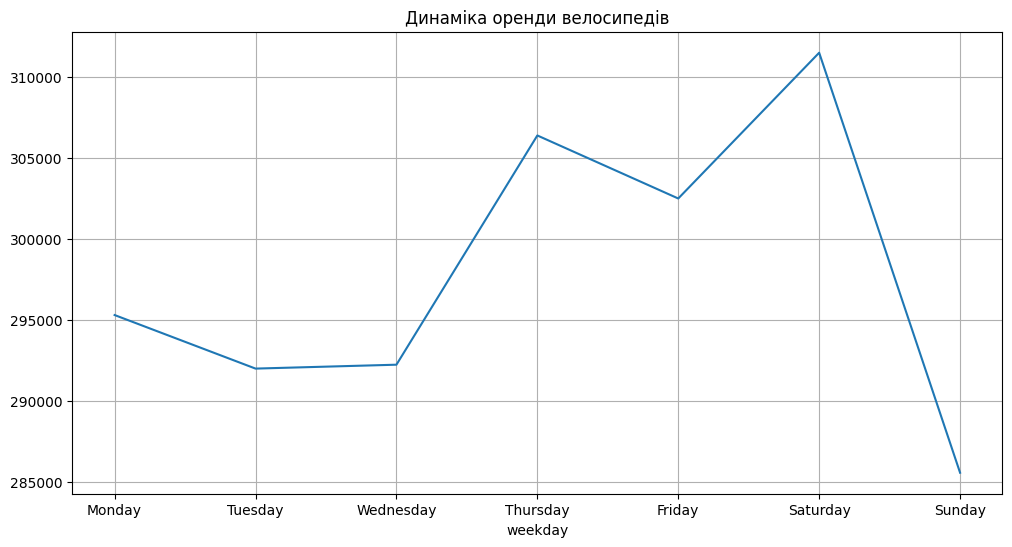

In [94]:
order_day = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.weekday = pd.Categorical(df['weekday'], categories=order_day, ordered=True)
result = df.groupby('weekday')['count'].sum()
result.plot(
    figsize=(12,6),
    title="Динаміка оренди велосипедів",
    grid=True
)
plt.show()

1. Він має заломи, тому що на них знаходяться максимальні точки (кількість прокатів) за день, і потім графік з'єднується з іншою точкою. Щоб їх прибрати можна додати маркет для приховування заломів
2. Протягом тижня є запити на прокат, графік поступово наростає після вихідних і в суботу має пік
3. Помітно що в суботу найбільший пік (вихідний день)
4. Найбільший пік у суботу - можливо пов'язано з тим, що це вихідний день і люди обирають активний вид відпочинку для свого вихідного дня. У неділю найменше значення, люди готуються до наступного робочого тижня і можливо не обирають активності


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

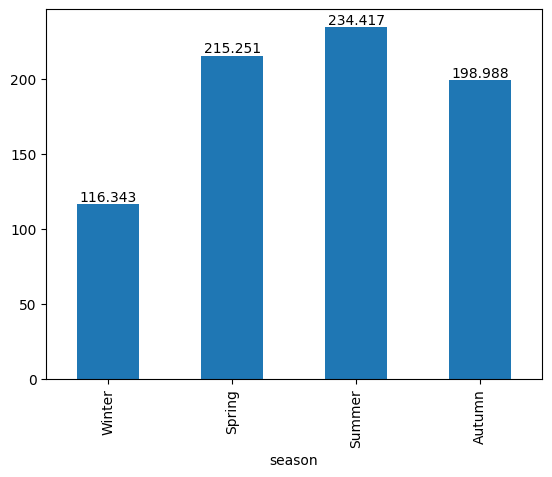

In [93]:
res = df.groupby('season')['count'].mean().rename({
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Autumn'
    }).plot.bar()
res.bar_label(res.containers[0])
plt.show()

1. Найбільша кількість замовлень у 3 кварталі (влітку)
2. Більшість людей йдуть у відпустки, гарна сонячна погода, люди хочуть спробвати нові активності
3. Різниця між 3 кварталом (найбільший) і 1 квартал (найменший) різниця у 2 рази

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


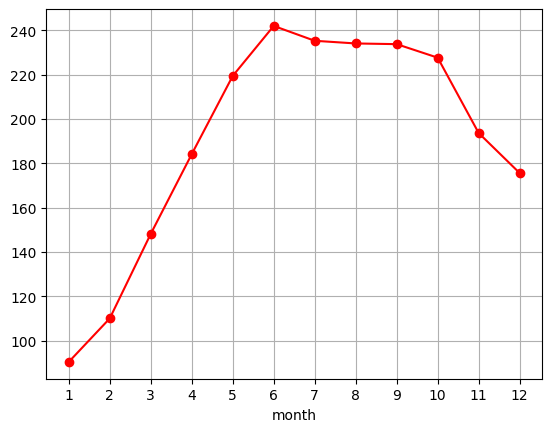

In [92]:
df.groupby('month')['count'].mean().plot.line(
    marker='o',
    grid=True,
    color='red',
    xticks=range(1,13)
)
plt.show()

1. Пік у 6 місяці (червень), найбільший спад у 1 місяці (січень)
2. Так, закономірність збігається з попереднім висновком
3. Чим тепліше у країні, або теплий сезон, то оренда буде більша. Якщо холодно, дощова погода - оренда відповідно менша

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

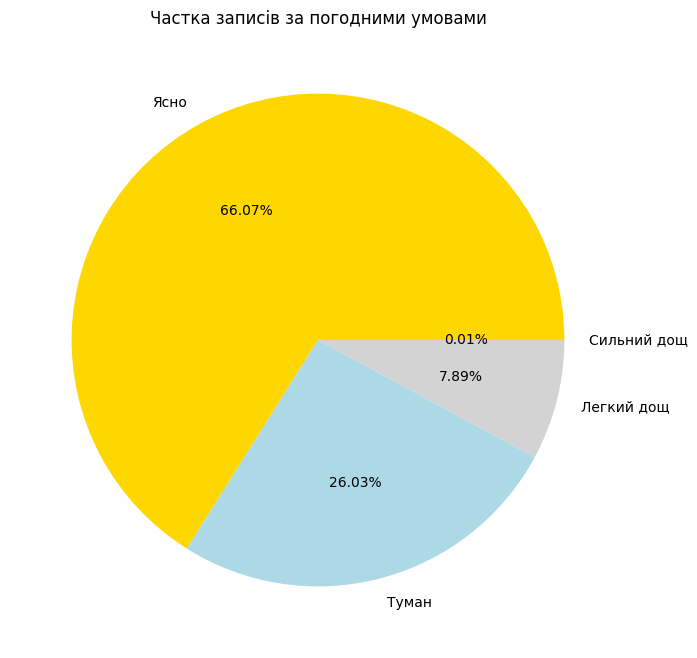

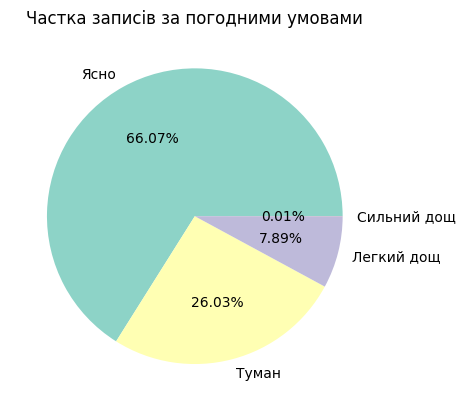

In [91]:
df['weather'].value_counts(normalize=True).plot.pie(
    autopct="%1.2f%%",
    labels=["Ясно", "Туман", "Легкий дощ", "Сильний дощ"],
    title = "Частка записів за погодними умовами",
    ylabel = '',
    colors = plt.cm.Set3.colors
)
plt.show()

1. Найбільше у датасеті записів з ясною погодою
2. Так, є дуже мала частка з сильним дощем - 0.01 %
3. Більшість людей не має бажання брати в оренду велосипеди через дощ або туман, адже вони впливають на сам процес катання на велосипедах, роблячи це незручно, а також вищий ризик аварійних ситуацій через погодні умови

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

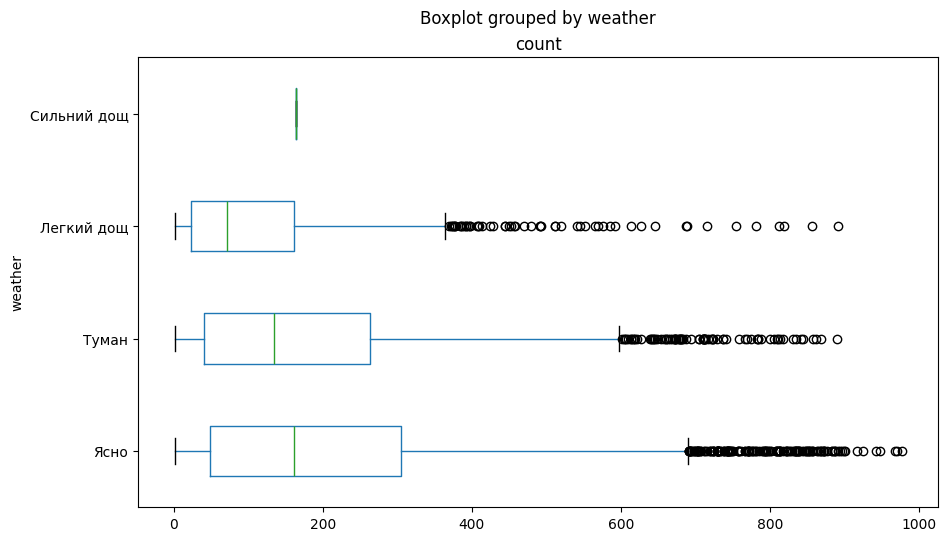

In [90]:
df.boxplot(
    column = 'count',
    by = 'weather',
    figsize=(10,6),
    grid=False,
    vert=False
    )
plt.yticks(
    ticks = [1, 2, 3, 4],
    labels = ["Ясно", "Туман", "Легкий дощ", "Сильний дощ"]
)
plt.show()

1. Найбільший розкид в ясній погоді
2. Є викиди. У ясній погоді, тумані та легкому дощі
3. Найбільше медіанне значення при сильному дощі

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

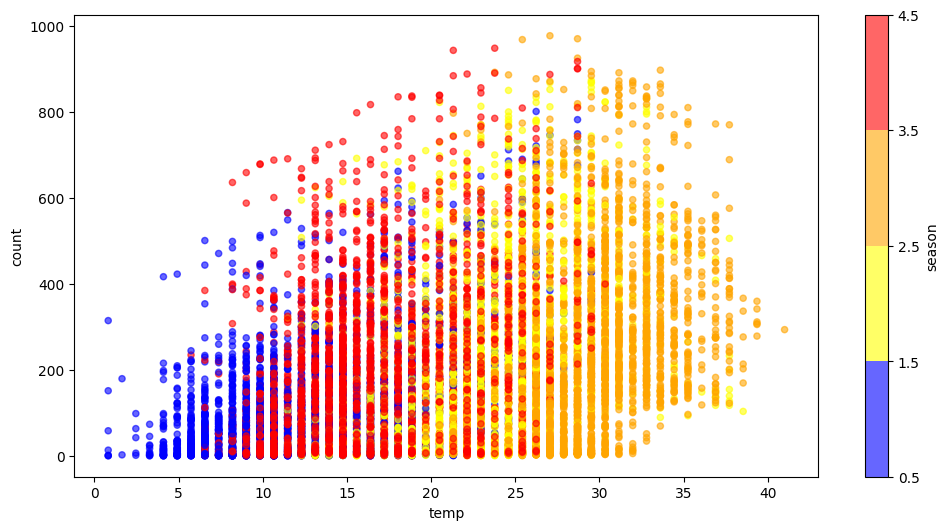

In [119]:
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ListedColormap(["blue", "yellow", "orange", "red"])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], colors.N)

df.plot.scatter(
    x = 'temp',
    y = 'count',
    c = 'season',
    colormap = colors,
    norm = norm,
    figsize = (12,6),
    alpha=0.6
)
plt.show()

Можливо, є нелінійний позитивний зв'язок. Адже тут немає чіткої лінії, щоб був лінійний зв'язок, і значення позитивні. І більше оренди у теплу погоду. У заналдто холодну та жарку погоду попит знижується

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

/tmp/ipykernel_528/3223428756.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("weekday")[["casual","registered"]].mean().plot.bar(


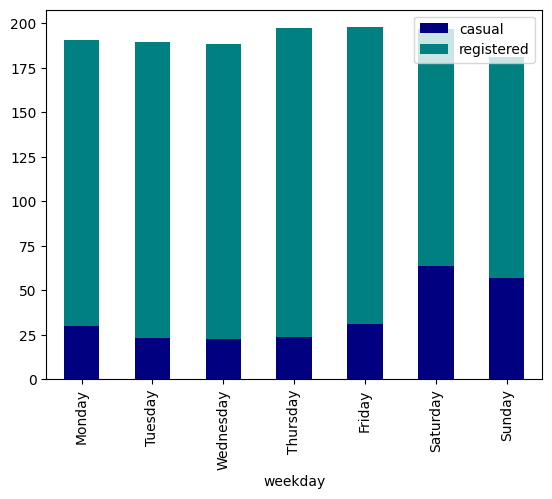

In [146]:
from matplotlib.colors import ListedColormap
colors = ListedColormap(["navy", "teal"])
df.groupby("weekday")[["casual","registered"]].mean().plot.bar(
    stacked=True,
    colormap = colors
)
plt.show()

1. Від зареєстрованих користувачів більше оренд в період четвер-субота
2. Зареєстровані користувачі мають більше доступу до інформації. Можливо є якісь акції, вигідні пропозиції, тому вони можуть брати в оренду і не в пікові дні. Незареєстровані користувачі зазвичай беруть на вихідні для відпочинку